<a href="https://colab.research.google.com/github/ZeyadSalah134/CarPower-Speed_Predictions-NTI-Project-/blob/main/Another_copy_of_speed_car_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

from sklearn.feature_selection import SelectKBest, f_regression, RFE

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [ ]:
df=pd.read_csv(r'/content/DriveArabia_All_uae_updated.csv')
df.head(10)

,Link,Approx Cost,Origin Country,Sale Country,Manufacturer,Brand,Model Year,Body Type,Additional Type,Weight,Gear box,Power (hp),Torque (Nm),Fuel Econ (L/100km),Fuel Econ (km/L),Performance 0-100 kph (sec),Top speed (kph),Overview
0,https://www.drivearabia.com/carprices/uae/merc...,"AED 37,200 - 61,000",Germany,uae,Mercedes-Benz,CLS-Class,2006,Luxury Midsize Sedan,4-door sedan,1730 - \r\n 1920,7A,272,350,10.1,9.9,7,250*,The new CLS combines the elegance of a coupÃ© ...
1,https://www.drivearabia.com/carprices/uae/jeep...,"AED 67,700 - 69,900 (Sport)",United States,uae,Jeep,Wrangler Unlimited,2015,Midsize SUV,5-door wagon,1973,6M/5A,285,352,11.4,8.8,8.1,157*,"The Wrangler was redesigned for 2007, with a s..."
2,https://www.drivearabia.com/carprices/uae/niss...,"AED 22,700 - 24,700 (Panel Van)",Japan,uae,Nissan,Urvan,2007,Commercial Midsize Van,4-door/5-door Van,1675 - 1810,5M,144,213,12,8.3,14.0-17.0,170,The Nissan Urvan has been a commercial success...
3,https://www.drivearabia.com/carprices/uae/lamb...,"AED 602,300 - 697,400",Italy,uae,Lamborghini,Huracan Spyder,2017,Premium Sports Coupe,2-door convertible,1422,7AM,610,560,12.3,8.1,3.4,324,"The Lamborghini HuracÃ¡n, named after yet anot..."
4,https://www.drivearabia.com/carprices/uae/dodg...,"AED 166,400 - 185,600 (SRT HellCat)",Canada,uae,Dodge,Charger SRT,2019,Premium Large Sedan,Premium Large Sedan,1797 - 1984,8A,485,643,12.5,8,4.8,280,The 2015 Dodge Charger SRT received a signific...
5,https://www.drivearabia.com/carprices/uae/bmw/...,"AED 39,600 - 41,400 (320i)",Germany,uae,BMW,3-Series Convertible,2010,Premium Compact Convertible,2-door convertible,1700 - 1825,7A,170,210,7.3,13.7,9.8,226,The 5th-generation 3-Series convertible was in...
6,https://www.drivearabia.com/carprices/uae/ssan...,"AED 18,400 - 20,800",South Korea,uae,Ssangyong,Kyron,2013,Compact SUV,5-door wagon,1971 - 2046,5M/4A,150,214,11.7-12.6,8.5,15.5-16.5,160,The Kyron is this Korean carmaker's entry into...
7,https://www.drivearabia.com/carprices/uae/merc...,"AED 105,500 - 118,400 (E200)",Germany,uae,Mercedes-Benz,E-Class,2018,Luxury Midsize Sedan,4-door sedan,1605 - 1830,9A,184,300,5.9,16.9,7.7,240,An all-new Mercedes-Benz E-Class sedan made it...
8,https://www.drivearabia.com/carprices/uae/toyo...,"AED 18,500 - 22,500",United States,uae,Toyota,Avalon,2006,Premium Large Sedan,4-door sedan,1586 - 1636,5A/6A,268,336,9,11.1,7.2,208*,The new Avalon is Toyota's rendition of the tr...
9,https://www.drivearabia.com/carprices/uae/mini...,"AED 77,200 - 80,000 (Cooper)",United Kingdom,uae,Mini,Cooper 5-door,2016,Mini Hatchback,5-door hatchback,1190 - 1250,6M/6A,136,219,5.4,18.5,7.8,210,Mini released an all-new Cooper and Cooper S 5...


In [ ]:
df.shape

(7647, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7647 entries, 0 to 7646
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Link                         7647 non-null   object
 1   Approx Cost                  7647 non-null   object
 2   Origin Country               7642 non-null   object
 3   Sale Country                 7647 non-null   object
 4   Manufacturer                 7647 non-null   object
 5   Brand                        7647 non-null   object
 6   Model Year                   7647 non-null   int64 
 7   Body Type                    7647 non-null   object
 8   Additional Type              7646 non-null   object
 9   Weight                       7588 non-null   object
 10  Gear box                     7647 non-null   object
 11  Power (hp)                   7646 non-null   object
 12  Torque (Nm)                  7646 non-null   object
 13  Fuel Econ (L/100km)          7635

In [ ]:
df.isnull().sum()

,0
Link,0
Approx Cost,0
Origin Country,5
Sale Country,0
Manufacturer,0
Brand,0
Model Year,0
Body Type,0
Additional Type,1
Weight,59


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Link,7647
Approx Cost,6662
Origin Country,43
Sale Country,1
Manufacturer,89
Brand,960
Model Year,37
Body Type,107
Additional Type,68
Weight,1212


In [ ]:
df.drop(['Link','Overview','Sale Country'],axis=1,inplace=True)

In [ ]:
for col in df.select_dtypes(include="object").columns:

    print(df[col].value_counts().head(10))
    print()

Approx Cost
Not Sold Here                42
Coming Soon                  21
Not Sold in UAE              17
Not Sold in UAE.             12
AED 54,000 - 80,000          11
AED 4,330,000 - 5,078,000    10
AED 36,000 - 68,000           9
AED 150,000 - 155,000         9
AED 90,000 - 110,000          8
AED 995,000 - 1,350,000       8
Name: count, dtype: int64

Origin Country
Germany           1421
Japan             1250
United States     1176
South Korea        661
China              472
United Kingdom     371
France             312
Italy              271
Thailand           212
Canada             205
Name: count, dtype: int64

Manufacturer
Mercedes-Benz    582
BMW              430
Toyota           373
Nissan           336
Audi             336
Ford             309
Chevrolet        303
Hyundai          274
Volkswagen       255
Kia              225
Name: count, dtype: int64

Brand
6               31
LX              25
Land Cruiser    25
Accord          25
G-Class         25
Patrol          25

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

) missing from font(s) DejaVu Sans.



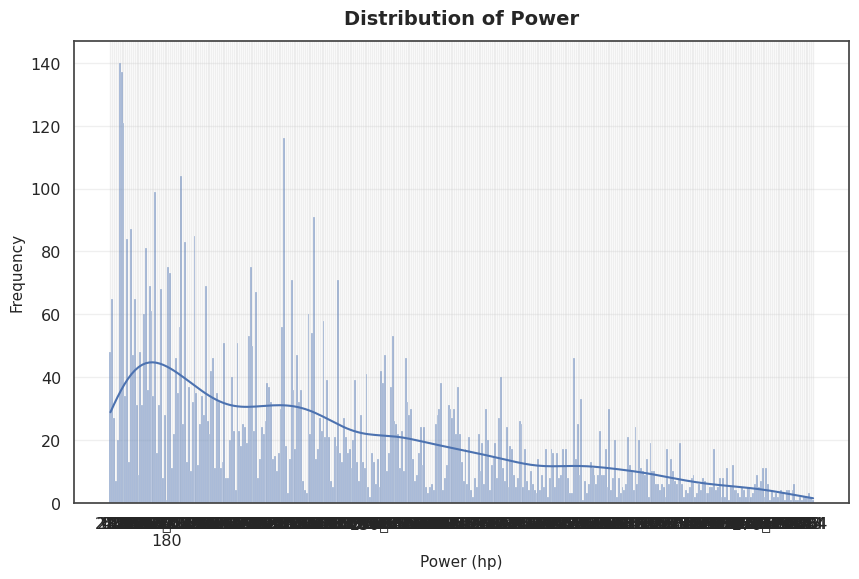

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["Power (hp)"], kde=True)
plt.title("Distribution of Power")
plt.xlabel("Power (hp)")
plt.ylabel("Frequency")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

) missing from font(s) DejaVu Sans.



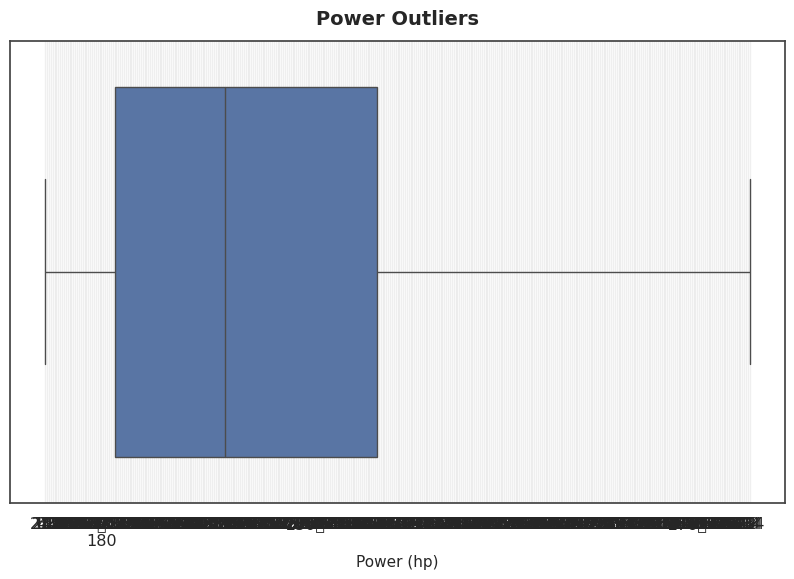

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df["Power (hp)"])
plt.title("Power Outliers")
plt.xlabel("Power (hp)")
plt.show()

In [ ]:
df.dtypes

,0
Approx Cost,object
Origin Country,object
Manufacturer,object
Brand,object
Model Year,int64
Body Type,object
Additional Type,object
Weight,object
Gear box,object
Power (hp),object


In [ ]:
for col in ["Weight", "Torque (Nm)", "Fuel Econ (km/L)","Fuel Econ (L/100km)", "Performance 0-100 kph (sec)", "Top speed (kph)", "Power (hp)"]:
    print("\n", col)
    print(df[col].dropna().astype(str).head(15).tolist())


 Weight
['1730 - \r\n    1920', '1973', '1675 - 1810', '1422', '1797 - 1984', '1700 - 1825', '1971 - 2046', '1605 - 1830', '1586 - 1636', '1190 - 1250', '1525', '1301', '2134 - 2214', '1520 - 1550', '1300 - 1315']

 Torque (Nm)
['350', '352', '213', '560', '643', '210', '214', '300', '336', '219', '380', '208', '346', '250', '200']

 Fuel Econ (km/L)
['9.9', '8.8', '8.3', '8.1', '8', '13.7', '8.5', '16.9', '11.1', '18.5', '14.5', '9.7', '10', '14.3', '16.9']

 Fuel Econ (L/100km)
['10.1', '11.4', '12', '12.3', '12.5', '7.3', '11.7-12.6', '5.9', '9', '5.4', '6.9', '10.3', '10.0-10.3', '7', '5.9']

 Performance 0-100 kph (sec)
['7', '8.1', '14.0-17.0', '3.4', '4.8', '9.8', '15.5-16.5', '7.7', '7.2', '7.8', '4.9', '6.2', '9', '9.8', '9.5']

 Top speed (kph)
['250*', '157*', '170', '324', '280', '226', '160', '240', '208*', '210', '250*', '241', '173*', '200', '210']

 Power (hp)
['272', '285', '144', '610', '485', '170', '150', '184', '268', '136', '296', '240', '290', '148', '153']


In [ ]:
def convert_range(value):
    if pd.isna(value):
        return np.nan

    value = str(value).replace("\r", "").replace("\n", " ").strip()

    if "-" in value:
        parts = value.split("-")

        try:
            first = float(parts[0].strip())
            second = float(parts[1].strip())
            return (first + second) / 2
        except ValueError:
            return np.nan

    try:
        return float(value)
    except ValueError:
        return np.nan

In [ ]:
df["Weight"] = df["Weight"].apply(convert_range)
df["Fuel Econ (L/100km)"] = df["Fuel Econ (L/100km)"].apply(convert_range)
df["Performance 0-100 kph (sec)"] = df["Performance 0-100 kph (sec)"].apply(convert_range)

In [ ]:
df["Torque (Nm)"] = pd.to_numeric(df["Torque (Nm)"], errors="coerce")
df["Fuel Econ (km/L)"] = pd.to_numeric(df["Fuel Econ (km/L)"], errors="coerce")

In [ ]:
df["Top speed (kph)"] = df["Top speed (kph)"].astype(str).str.replace("*", "", regex=False)

In [ ]:
df["Top speed (kph)"] = pd.to_numeric(df["Top speed (kph)"], errors="coerce")

In [ ]:
df["Power (hp)"] = pd.to_numeric(df["Power (hp)"], errors="coerce")

In [ ]:
df.dtypes

,0
Approx Cost,object
Origin Country,object
Manufacturer,object
Brand,object
Model Year,int64
Body Type,object
Additional Type,object
Weight,float64
Gear box,object
Power (hp),float64


In [ ]:
df.isnull().sum()

,0
Approx Cost,0
Origin Country,5
Manufacturer,0
Brand,0
Model Year,0
Body Type,0
Additional Type,1
Weight,76
Gear box,0
Power (hp),3


In [ ]:
df = df.dropna(subset=["Power (hp)"])

In [ ]:
def convert_cost(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if "AED" not in value:
        return np.nan

    value = value.replace("AED", "").replace(",", "").strip()

    if "-" in value:
        parts = value.split("-")

        try:
            first = float(parts[0].strip())
            second = float(parts[1].strip())
            return (first + second) / 2
        except ValueError:
            return np.nan

    try:
        return float(value)
    except ValueError:
        return np.nan

In [ ]:
df["Approx Cost"] = df["Approx Cost"].apply(convert_cost)

In [ ]:
df["Approx Cost"].head(20)

,Approx Cost
0,49100.0
1,NaN
2,NaN
3,649850.0
4,NaN
5,NaN
6,19600.0
7,NaN
8,20500.0
9,NaN


In [ ]:
df["Approx Cost"].dtype

dtype('float64')

In [ ]:
df[df["Brand"].str.contains(r"-(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)$", regex=True)]

/tmp/ipykernel_3750/3787756894.py:1: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.



,Approx Cost,Origin Country,Manufacturer,Brand,Model Year,Body Type,Additional Type,Weight,Gear box,Power (hp),Torque (Nm),Fuel Econ (L/100km),Fuel Econ (km/L),Performance 0-100 kph (sec),Top speed (kph)
97,149500.0,Sweden,Saab,3-Sep,2011,Premium Midsize Sedan / Wagon /,"4-door sedan, 5-door wagon, 2-door convertible",1607.5,5M/5A,150.0,240.0,8.4,13.5,10.5,NaN
414,149500.0,Sweden,Saab,3-Sep,2008,Premium Midsize Sedan / Wagon /,"4-door sedan, 5-door wagon, 2-door convertible",1607.5,5M/5A,150.0,240.0,8.4,13.5,10.5,NaN
540,152500.0,Sweden,Saab,5-Sep,2009,Premium Midsize Sedan,4-door sedan,1574.5,5M/5A,185.0,280.0,9.6,11.2,9.1,NaN
600,139500.0,Sweden,Saab,3-Sep,2005,Premium Midsize Sedan / Wagon /,"4-door sedan, 5-door wagon, 2-door convertible",1601.0,5M/5A,150.0,240.0,8.4,13.5,10.5,NaN
622,139500.0,Sweden,Saab,3-Sep,2006,Premium Midsize Sedan / Wagon /,"4-door sedan, 5-door wagon, 2-door convertible",1601.0,5M/5A,150.0,240.0,8.4,13.5,10.5,NaN
1360,152500.0,Sweden,Saab,5-Sep,2008,Premium Midsize Sedan,4-door sedan,1574.5,5M/5A,185.0,280.0,9.6,11.2,9.1,NaN
1823,149500.0,Sweden,Saab,3-Sep,2010,Premium Midsize Sedan / Wagon /,"4-door sedan, 5-door wagon, 2-door convertible",1607.5,5M/5A,150.0,240.0,8.4,13.5,10.5,NaN
1875,139500.0,Sweden,Saab,3-Sep,2007,Premium Midsize Sedan / Wagon /,"4-door sedan, 5-door wagon, 2-door convertible",1601.0,5M/5A,150.0,240.0,8.4,13.5,10.5,NaN
1895,149500.0,Sweden,Saab,3-Sep,2009,Premium Midsize Sedan / Wagon /,"4-door sedan, 5-door wagon, 2-door convertible",1607.5,5M/5A,150.0,240.0,8.4,13.5,10.5,NaN
2347,152500.0,Sweden,Saab,5-Sep,2006,Premium Midsize Sedan,4-door sedan,1574.5,5M/5A,185.0,280.0,9.6,11.2,9.1,NaN


In [ ]:
suspicious = df[df["Brand"].str.contains(r"\d+-[A-Za-z]{3}$", regex=True, na=False)]
print(suspicious["Brand"].unique())

['3-Sep' '5-Sep']


In [ ]:
df["Brand"] = df["Brand"].str.replace("3-Sep", "9-3", regex=False)
df["Brand"] = df["Brand"].str.replace("5-Sep", "9-5", regex=False)

In [ ]:
print(df[df["Brand"].str.contains("Saab", na=False)]["Brand"].unique())

[]


In [ ]:
df["Brand_Manufacturer"] = (
    df["Manufacturer"].fillna("") + " " + df["Brand"].fillna("")
)

df["Brand_Manufacturer"] = df["Brand_Manufacturer"].str.strip()

df.drop(["Brand", "Manufacturer"], axis=1, inplace=True)

In [ ]:
print((df["Brand_Manufacturer"] == "").sum())

0


In [ ]:
df['Brand_Manufacturer'].unique()

array(['Mercedes-Benz CLS-Class', 'Jeep Wrangler Unlimited',
       'Nissan Urvan', 'Lamborghini Huracan Spyder', 'Dodge Charger SRT',
       'BMW 3-Series Convertible', 'Ssangyong Kyron',
       'Mercedes-Benz E-Class', 'Toyota Avalon', 'Mini Cooper 5-door',
       'Audi S3', 'Honda S2000', 'Ford Explorer',
       'Mitsubishi Eclipse Cross', 'Mazda 3 Sedan',
       'Mercedes-Benz AMG GT', 'Ford Fusion', 'Lexus LX',
       'Infiniti Q60 Coupe', 'Peugeot 206', 'Mercedes-Benz S 65 AMG',
       'Opel Astra', 'Nissan X-Trail', 'BMW X4', 'Honda Civic Hatchback',
       'Mercedes-Benz C 63 AMG', 'BMW X3', 'Kia Sportage',
       'Toyota Corolla Cross', 'Ferrari 488 Spider', 'Subaru Impreza WRX',
       'Volkswagen Eos', 'Audi Q3 Sportback', 'Dongfeng H30 Cross',
       'Peugeot 208', 'Nissan Sunny', 'Mazda CX-9', 'Bentley Flying Spur',
       'BMW 4-Series', 'Ford Crown Victoria', 'Citroen C4',
       'Ford Mustang Convertible', 'Kia Sorento', 'BMW 6-Series Coupe',
       'Mazda B-Series', 'B

In [ ]:
df.isnull().sum()

,0
Approx Cost,3232
Origin Country,5
Model Year,0
Body Type,0
Additional Type,1
Weight,74
Gear box,0
Power (hp),0
Torque (Nm),3
Fuel Econ (L/100km),67


In [ ]:
df["gear_count"] = df["Gear box"].str.extract(r"(\d+)").astype(float)
df["gear_type"] = df["Gear box"].str.findall(r"AM|AT|CVT|M|A").apply(lambda x: "/".join(dict.fromkeys(x)))
df["gear_type"] = df["gear_type"].apply(lambda x: "/".join(sorted(x.split("/"))))

In [ ]:
df['gear_type'].unique()

array(['A', 'A/M', 'M', 'AM', 'CVT', 'CVT/M', 'AM/M', 'A/CVT', 'A/AM',
       'AT'], dtype=object)

In [ ]:
df.head()

,Approx Cost,Origin Country,Model Year,Body Type,Additional Type,Weight,Gear box,Power (hp),Torque (Nm),Fuel Econ (L/100km),Fuel Econ (km/L),Performance 0-100 kph (sec),Top speed (kph),Brand_Manufacturer,gear_count,gear_type
0,49100.0,Germany,2006,Luxury Midsize Sedan,4-door sedan,1825.0,7A,272.0,350.0,10.1,9.9,7.0,250.0,Mercedes-Benz CLS-Class,7.0,A
1,NaN,United States,2015,Midsize SUV,5-door wagon,1973.0,6M/5A,285.0,352.0,11.4,8.8,8.1,157.0,Jeep Wrangler Unlimited,6.0,A/M
2,NaN,Japan,2007,Commercial Midsize Van,4-door/5-door Van,1742.5,5M,144.0,213.0,12.0,8.3,15.5,170.0,Nissan Urvan,5.0,M
3,649850.0,Italy,2017,Premium Sports Coupe,2-door convertible,1422.0,7AM,610.0,560.0,12.3,8.1,3.4,324.0,Lamborghini Huracan Spyder,7.0,AM
4,NaN,Canada,2019,Premium Large Sedan,Premium Large Sedan,1890.5,8A,485.0,643.0,12.5,8.0,4.8,280.0,Dodge Charger SRT,8.0,A


In [ ]:
df.drop('Gear box',axis=1,inplace=True)

In [ ]:
df['gear_type_encoded']=df['gear_type'].copy()

In [ ]:
df = pd.get_dummies(df, columns=["gear_type_encoded"], drop_first=True)

In [ ]:
df.head()

,Approx Cost,Origin Country,Model Year,Body Type,Additional Type,Weight,Power (hp),Torque (Nm),Fuel Econ (L/100km),Fuel Econ (km/L),...,gear_type,gear_type_encoded_A/AM,gear_type_encoded_A/CVT,gear_type_encoded_A/M,gear_type_encoded_AM,gear_type_encoded_AM/M,gear_type_encoded_AT,gear_type_encoded_CVT,gear_type_encoded_CVT/M,gear_type_encoded_M
0,49100.0,Germany,2006,Luxury Midsize Sedan,4-door sedan,1825.0,272.0,350.0,10.1,9.9,...,A,False,False,False,False,False,False,False,False,False
1,NaN,United States,2015,Midsize SUV,5-door wagon,1973.0,285.0,352.0,11.4,8.8,...,A/M,False,False,True,False,False,False,False,False,False
2,NaN,Japan,2007,Commercial Midsize Van,4-door/5-door Van,1742.5,144.0,213.0,12.0,8.3,...,M,False,False,False,False,False,False,False,False,True
3,649850.0,Italy,2017,Premium Sports Coupe,2-door convertible,1422.0,610.0,560.0,12.3,8.1,...,AM,False,False,False,True,False,False,False,False,False
4,NaN,Canada,2019,Premium Large Sedan,Premium Large Sedan,1890.5,485.0,643.0,12.5,8.0,...,A,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Approx Cost,3232
Origin Country,5
Model Year,0
Body Type,0
Additional Type,1
Weight,74
Power (hp),0
Torque (Nm),3
Fuel Econ (L/100km),67
Fuel Econ (km/L),58


In [ ]:
df

,Approx Cost,Origin Country,Model Year,Body Type,Additional Type,Weight,Power (hp),Torque (Nm),Fuel Econ (L/100km),Fuel Econ (km/L),...,gear_type,gear_type_encoded_A/AM,gear_type_encoded_A/CVT,gear_type_encoded_A/M,gear_type_encoded_AM,gear_type_encoded_AM/M,gear_type_encoded_AT,gear_type_encoded_CVT,gear_type_encoded_CVT/M,gear_type_encoded_M
0,49100.0,Germany,2006,Luxury Midsize Sedan,4-door sedan,1825.0,272.0,350.0,10.1,9.9,...,A,False,False,False,False,False,False,False,False,False
1,NaN,United States,2015,Midsize SUV,5-door wagon,1973.0,285.0,352.0,11.4,8.8,...,A/M,False,False,True,False,False,False,False,False,False
2,NaN,Japan,2007,Commercial Midsize Van,4-door/5-door Van,1742.5,144.0,213.0,12.0,8.3,...,M,False,False,False,False,False,False,False,False,True
3,649850.0,Italy,2017,Premium Sports Coupe,2-door convertible,1422.0,610.0,560.0,12.3,8.1,...,AM,False,False,False,True,False,False,False,False,False
4,NaN,Canada,2019,Premium Large Sedan,Premium Large Sedan,1890.5,485.0,643.0,12.5,8.0,...,A,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7642,NaN,Germany,2014,Luxury Midsize Sedan,4-door sedan,1882.5,320.0,450.0,7.9,12.7,...,A,False,False,False,False,False,False,False,False,False
7643,20900.0,United States,2006,Luxury Large Sedan,4-door sedan,1849.0,255.0,339.0,11.3,9.0,...,A,False,False,False,False,False,False,False,False,False
7644,4100.0,Austria,2002,Compact Minivan,5-door hatchback,1497.0,143.0,188.0,9.1,11.9,...,A/M,False,False,True,False,False,False,False,False,False
7645,NaN,United Kingdom,2017,Luxury Large Sedan,"4-door sedan, 4-door long sedan",1841.5,240.0,340.0,8.9,11.2,...,A,False,False,False,False,False,False,False,False,False


<Axes: >

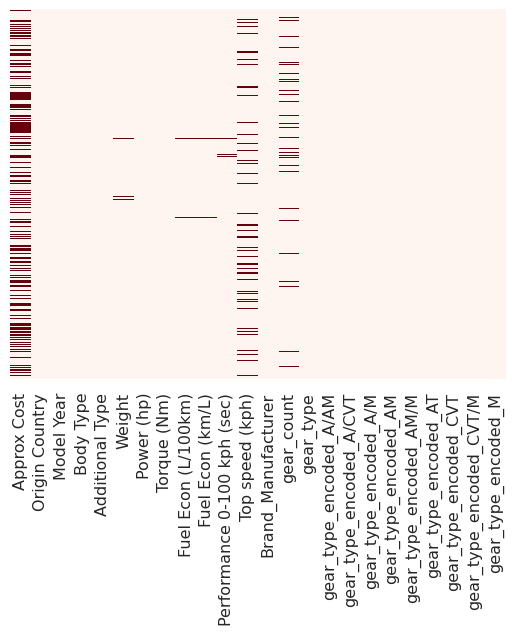

In [ ]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="Reds")

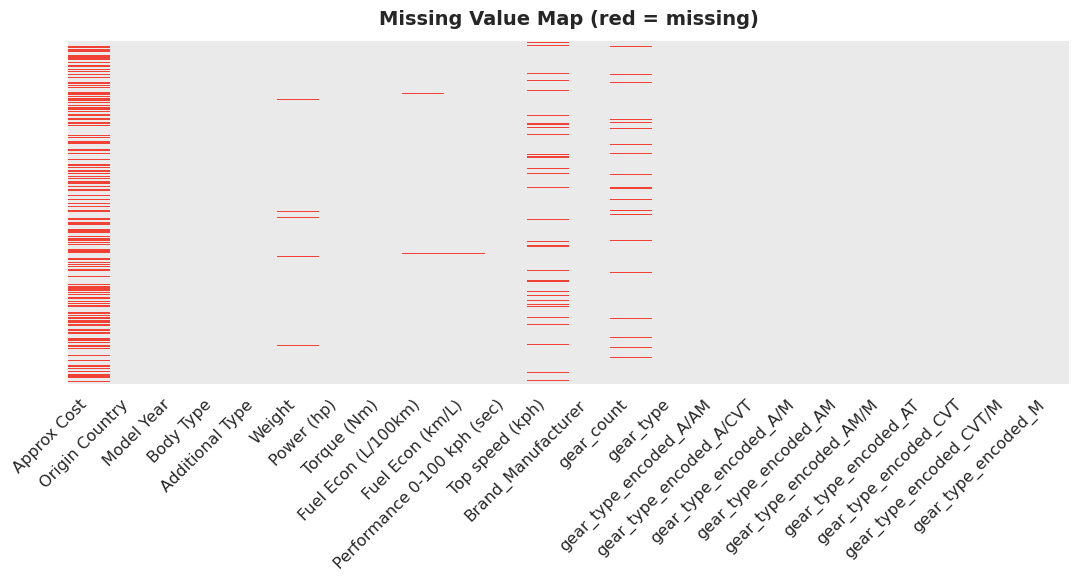

Missing % by column:
Approx Cost                    42.3%
Top speed (kph)                11.0%
gear_count                      5.6%
Weight                          1.0%
Fuel Econ (L/100km)             0.9%
Fuel Econ (km/L)                0.8%
Performance 0-100 kph (sec)     0.2%
Origin Country                  0.1%
Torque (Nm)                     0.0%
Additional Type                 0.0%
dtype: object


In [ ]:
pct_missing = df.isnull().mean() * 100
cols_with_na = pct_missing[pct_missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap=["#EAEAEA", ACCENT], ax=ax)
ax.set_title("Missing Value Map (red = missing)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if len(cols_with_na):
    print("Missing % by column:")
    print(cols_with_na.round(1).astype(str) + "%")
else:
    print("No missing values remaining.")

In [ ]:

num_cols = [
    "Weight",
    "Torque (Nm)",
    "Fuel Econ (L/100km)",
    "Fuel Econ (km/L)",
    "Performance 0-100 kph (sec)",
    "Top speed (kph)",
    "gear_count",
]

for col in num_cols:
    df[col] = df.groupby("Body Type")[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())




In [ ]:

categorical_cols = ["Origin Country", "Additional Type"]

for col in categorical_cols:
    df[col] = df.groupby("Brand_Manufacturer")[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
    )
    df[col] = df[col].fillna(df[col].mode()[0])


df["Approx Cost"] = df.groupby("Brand_Manufacturer")["Approx Cost"].transform(lambda x: x.fillna(x.median()))
df["Approx Cost"] = df["Approx Cost"].fillna(df["Approx Cost"].median())

In [ ]:
df.isnull().sum()

,0
Approx Cost,0
Origin Country,0
Model Year,0
Body Type,0
Additional Type,0
Weight,0
Power (hp),0
Torque (Nm),0
Fuel Econ (L/100km),0
Fuel Econ (km/L),0


In [ ]:
df.head()

,Approx Cost,Origin Country,Model Year,Body Type,Additional Type,Weight,Power (hp),Torque (Nm),Fuel Econ (L/100km),Fuel Econ (km/L),...,gear_type,gear_type_encoded_A/AM,gear_type_encoded_A/CVT,gear_type_encoded_A/M,gear_type_encoded_AM,gear_type_encoded_AM/M,gear_type_encoded_AT,gear_type_encoded_CVT,gear_type_encoded_CVT/M,gear_type_encoded_M
0,49100.0,Germany,2006,Luxury Midsize Sedan,4-door sedan,1825.0,272.0,350.0,10.1,9.9,...,A,False,False,False,False,False,False,False,False,False
1,30600.0,United States,2015,Midsize SUV,5-door wagon,1973.0,285.0,352.0,11.4,8.8,...,A/M,False,False,True,False,False,False,False,False,False
2,30600.0,Japan,2007,Commercial Midsize Van,4-door/5-door Van,1742.5,144.0,213.0,12.0,8.3,...,M,False,False,False,False,False,False,False,False,True
3,649850.0,Italy,2017,Premium Sports Coupe,2-door convertible,1422.0,610.0,560.0,12.3,8.1,...,AM,False,False,False,True,False,False,False,False,False
4,30600.0,Canada,2019,Premium Large Sedan,Premium Large Sedan,1890.5,485.0,643.0,12.5,8.0,...,A,False,False,False,False,False,False,False,False,False


In [ ]:
import plotly.express as px

num_cols = [
    "Weight",
    "Torque (Nm)",
    "Fuel Econ (L/100km)",
    "Fuel Econ (km/L)",
    "Performance 0-100 kph (sec)",
    "Top speed (kph)",
    "Approx Cost",
    "gear_count",
]

for col in num_cols:
    fig = px.box(
        df,
        y=col,
        points="outliers",
        color_discrete_sequence=["#4FB2C9"],
        title=f"{col} Distribution & Outliers",
        labels={col: col},
    )



    fig.show()

# *visulation*

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.titlepad": 12,
    "axes.labelsize": 11,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

PRIMARY  = "#2E86AB"
ACCENT   = "#F24236"
SEQ_CMAP = "viridis"
DIV_CMAP = "coolwarm"

PLOTLY_TEMPLATE = "plotly_white"

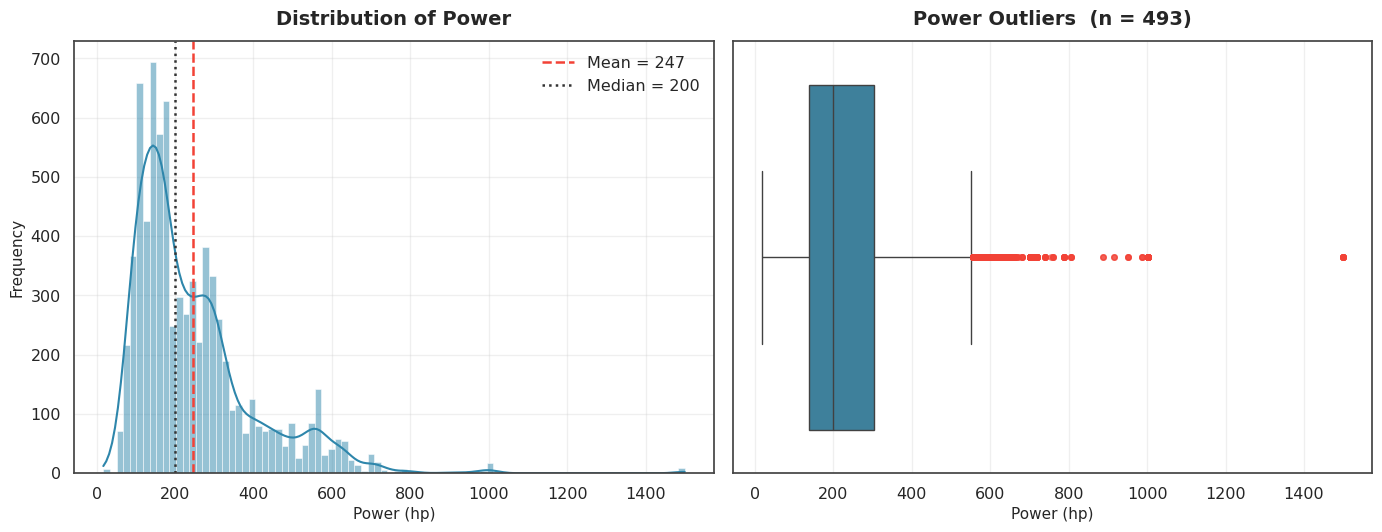

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.histplot(df["Power (hp)"], kde=True, color=PRIMARY, edgecolor="white", ax=axes[0])
mean_p, median_p = df["Power (hp)"].mean(), df["Power (hp)"].median()
axes[0].axvline(mean_p, color=ACCENT, ls="--", lw=1.8, label=f"Mean = {mean_p:.0f}")
axes[0].axvline(median_p, color="#333333", ls=":", lw=1.8, label=f"Median = {median_p:.0f}")
axes[0].set_title("Distribution of Power")
axes[0].set_xlabel("Power (hp)")
axes[0].set_ylabel("Frequency")
axes[0].legend(frameon=False)

sns.boxplot(x=df["Power (hp)"], color=PRIMARY, fliersize=4,
            flierprops=dict(markerfacecolor=ACCENT, markeredgecolor=ACCENT, alpha=0.6), ax=axes[1])
q1, q3 = df["Power (hp)"].quantile([0.25, 0.75])
iqr = q3 - q1
n_out = ((df["Power (hp)"] < q1 - 1.5*iqr) | (df["Power (hp)"] > q3 + 1.5*iqr)).sum()
axes[1].set_title(f"Power Outliers  (n = {n_out})")
axes[1].set_xlabel("Power (hp)")

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
from plotly.subplots import make_subplots

num_cols = [
    "Weight",
    "Torque (Nm)",
    "Fuel Econ (L/100km)",
    "Fuel Econ (km/L)",
    "Performance 0-100 kph (sec)",
    "Top speed (kph)",
    "Approx Cost",
    "gear_count",
]

n_cols_grid = 4
n_rows_grid = -(-len(num_cols) // n_cols_grid)

fig = make_subplots(rows=n_rows_grid, cols=n_cols_grid, subplot_titles=num_cols)

for i, col in enumerate(num_cols):
    r, c = divmod(i, n_cols_grid)
    fig.add_trace(
        go.Box(y=df[col], name=col, boxpoints="outliers",
               marker_color="#4FB2C9", line_color="#2E86AB", showlegend=False),
        row=r + 1, col=c + 1
    )

fig.update_layout(
    template=PLOTLY_TEMPLATE,
    title="Outlier Check — All Numeric Features",
    height=320 * n_rows_grid,
    margin=dict(t=90),
)
fig.show()

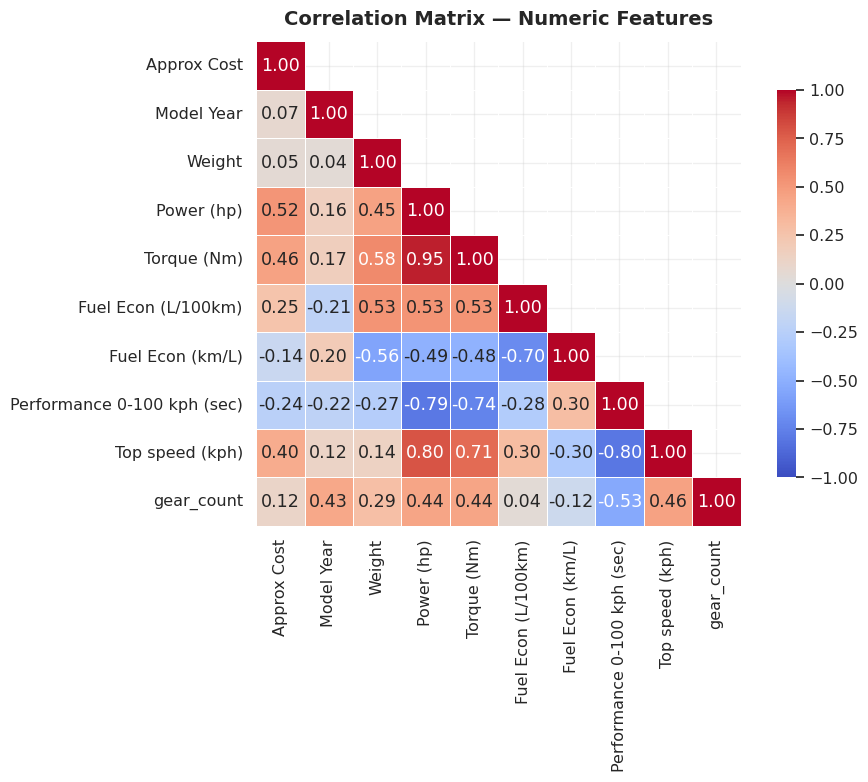

Correlation with Top speed (kph), sorted:
Power (hp)                     0.80
Torque (Nm)                    0.71
gear_count                     0.46
Approx Cost                    0.40
Fuel Econ (L/100km)            0.30
Weight                         0.14
Model Year                     0.12
Fuel Econ (km/L)              -0.30
Performance 0-100 kph (sec)   -0.80
Name: Top speed (kph), dtype: float64


In [ ]:
corr_cols = [
    "Approx Cost", "Model Year", "Weight", "Power (hp)", "Torque (Nm)",
    "Fuel Econ (L/100km)", "Fuel Econ (km/L)",
    "Performance 0-100 kph (sec)", "Top speed (kph)", "gear_count",
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=DIV_CMAP,
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

print("Correlation with Top speed (kph), sorted:")
print(corr["Top speed (kph)"].drop("Top speed (kph)").sort_values(ascending=False).round(2))

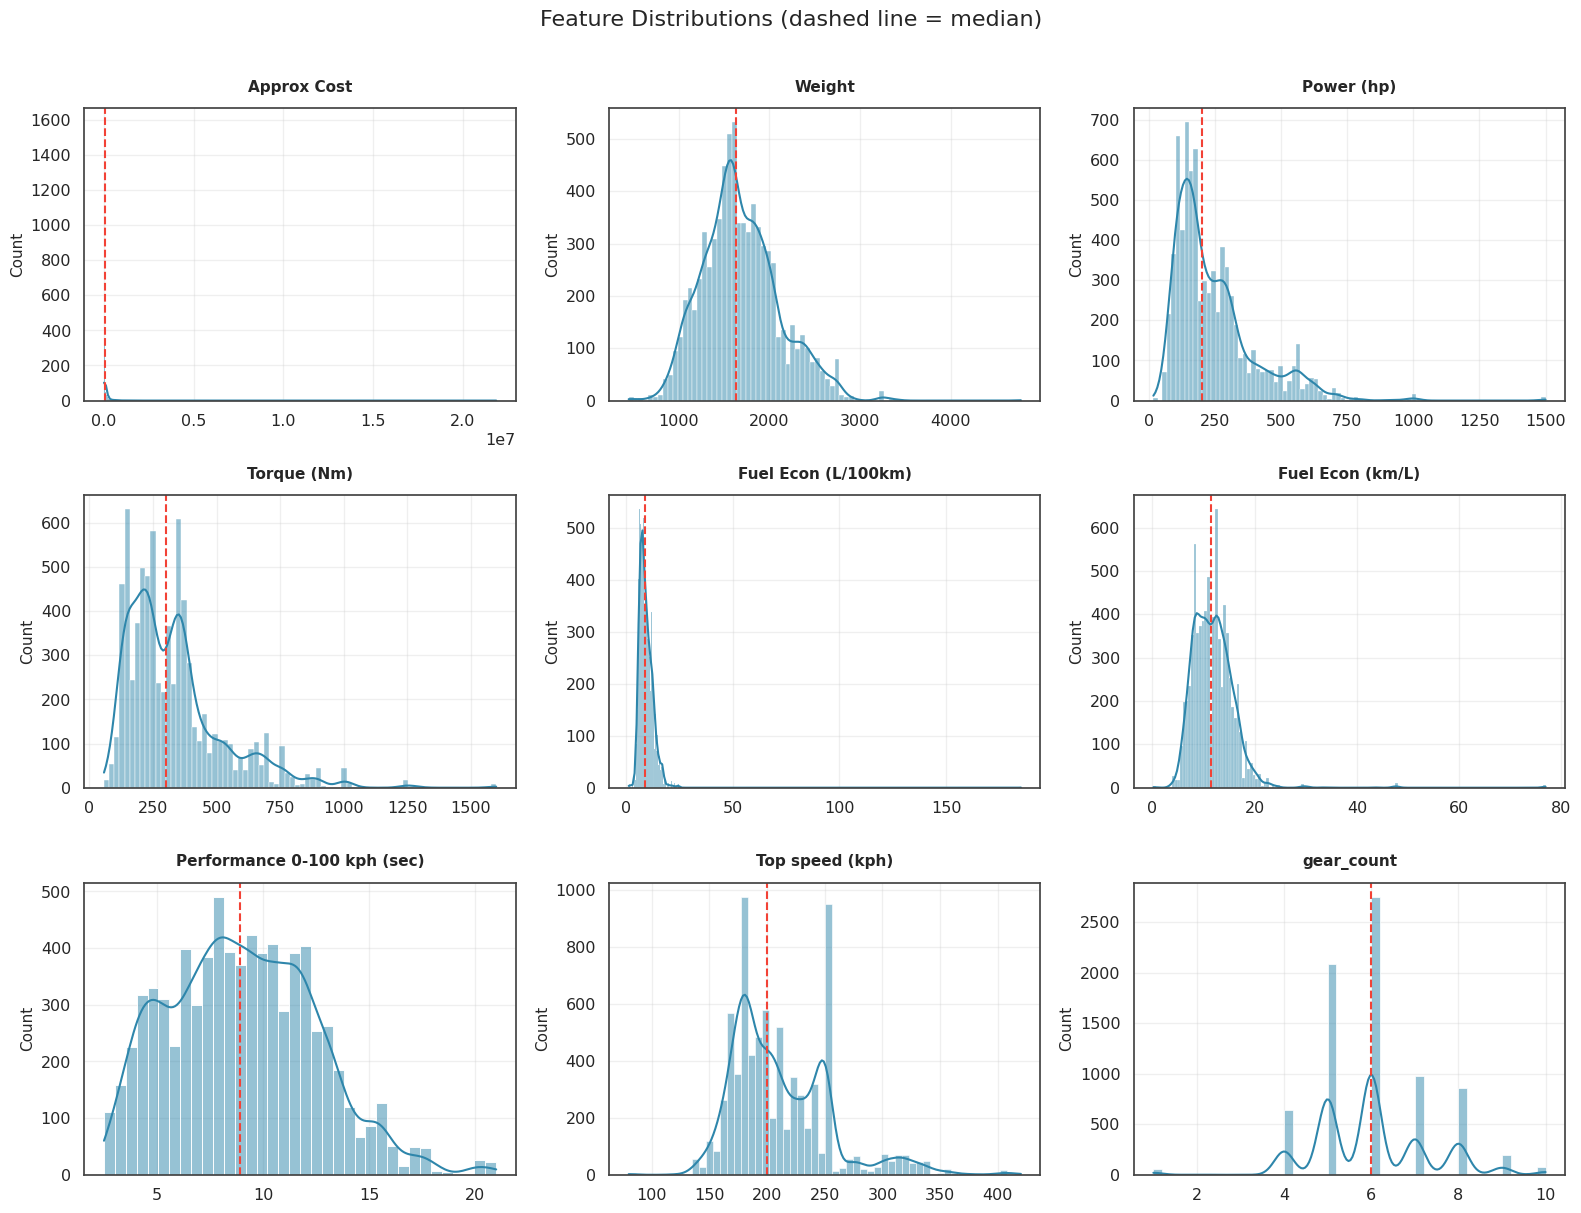

In [ ]:
dist_cols = [
    "Approx Cost", "Weight", "Power (hp)", "Torque (Nm)",
    "Fuel Econ (L/100km)", "Fuel Econ (km/L)",
    "Performance 0-100 kph (sec)", "Top speed (kph)", "gear_count",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, dist_cols):
    sns.histplot(df[col], kde=True, color=PRIMARY, edgecolor="white", ax=ax)
    ax.axvline(df[col].median(), color=ACCENT, ls="--", lw=1.5)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")

fig.suptitle("Feature Distributions (dashed line = median)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

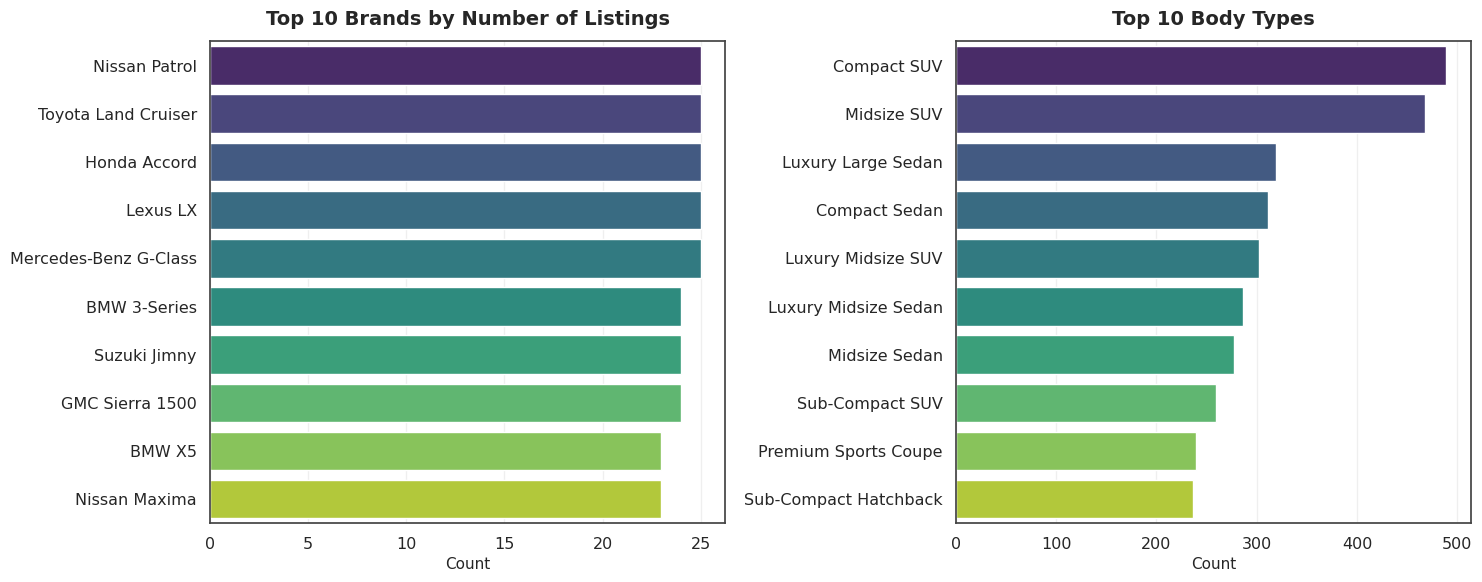

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_brands = df["Brand_Manufacturer"].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index,
            palette=SEQ_CMAP, legend=False, ax=axes[0])
axes[0].set_title("Top 10 Brands by Number of Listings")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

top_body = df["Body Type"].value_counts().head(10)
sns.barplot(x=top_body.values, y=top_body.index, hue=top_body.index,
            palette=SEQ_CMAP, legend=False, ax=axes[1])
axes[1].set_title("Top 10 Body Types")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
fig = px.scatter(
    df,
    x="Power (hp)",
    y="Top speed (kph)",
    size="Approx Cost",
    color="Body Type",
    hover_data=["Brand_Manufacturer", "Model Year"],
    trendline="ols",
    trendline_scope="overall",
    template=PLOTLY_TEMPLATE,
    title="Power vs. Top Speed (bubble size = Approx Cost)",
    opacity=0.75,
)
fig.update_layout(height=650, legend=dict(font=dict(size=9)))
fig.show()

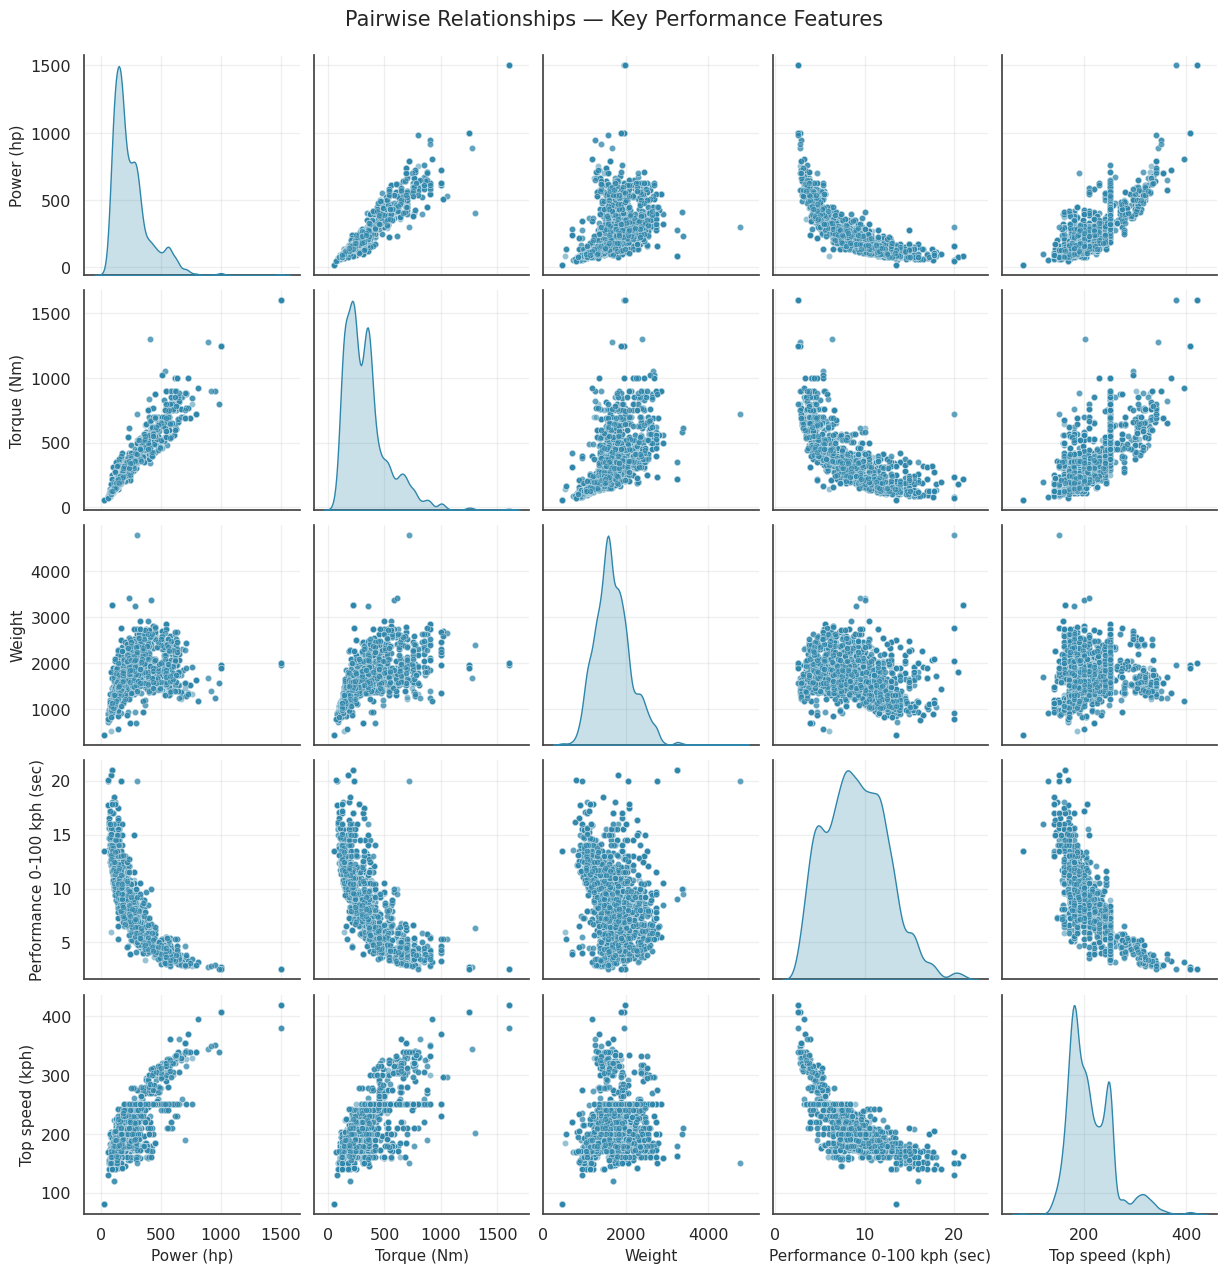

In [ ]:
pair_cols = ["Power (hp)", "Torque (Nm)", "Weight",
             "Performance 0-100 kph (sec)", "Top speed (kph)"]

g = sns.pairplot(
    df[pair_cols].dropna(),
    diag_kind="kde",
    plot_kws=dict(alpha=0.5, s=20, color=PRIMARY),
    diag_kws=dict(color=PRIMARY),
)
g.figure.suptitle("Pairwise Relationships — Key Performance Features", y=1.02, fontsize=15)
plt.show()

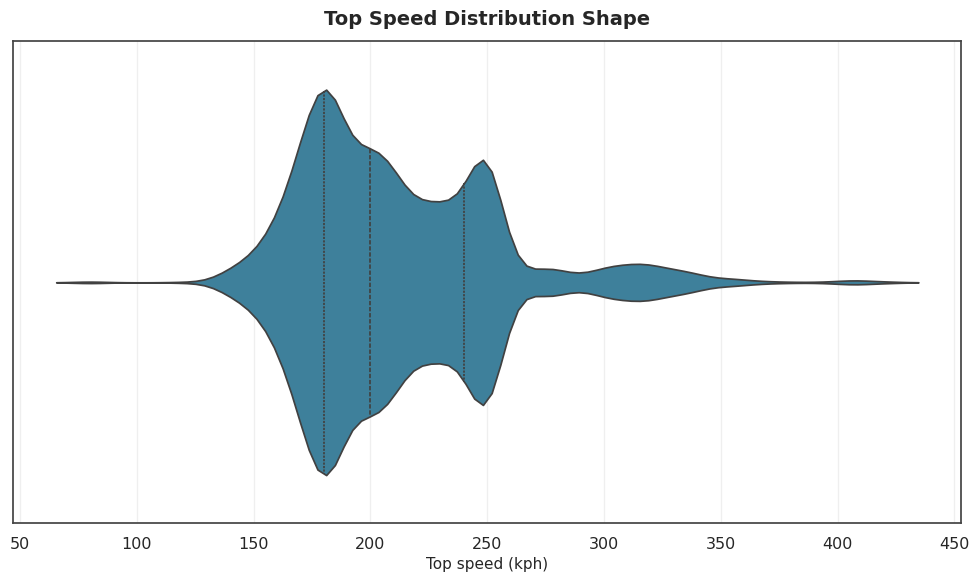

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(x=df["Top speed (kph)"], color=PRIMARY, inner="quartile", ax=ax)
ax.set_title("Top Speed Distribution Shape")
plt.tight_layout()
plt.show()

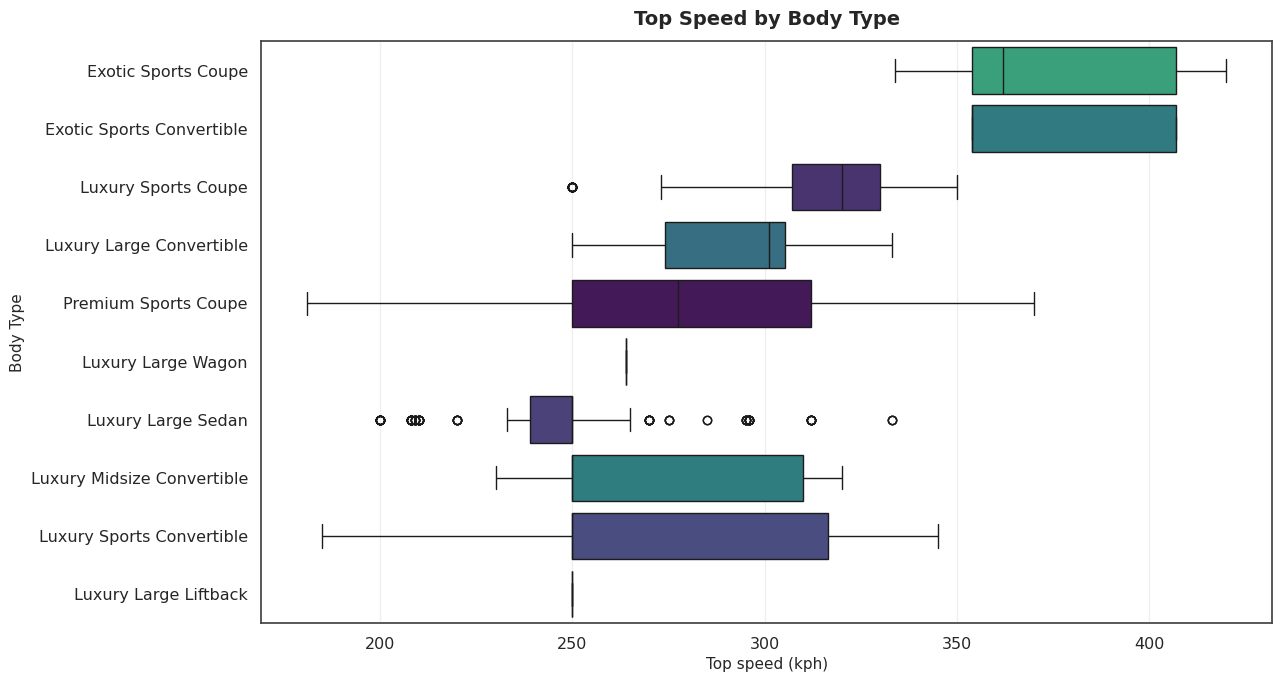

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))
order = df.groupby("Body Type")["Top speed (kph)"].median().sort_values(ascending=False).head(10).index
sns.boxplot(data=df, x="Top speed (kph)", y="Body Type", order=order, palette=SEQ_CMAP, hue="Body Type", legend=False, ax=ax)
ax.set_title("Top Speed by Body Type")
plt.tight_layout()
plt.show()

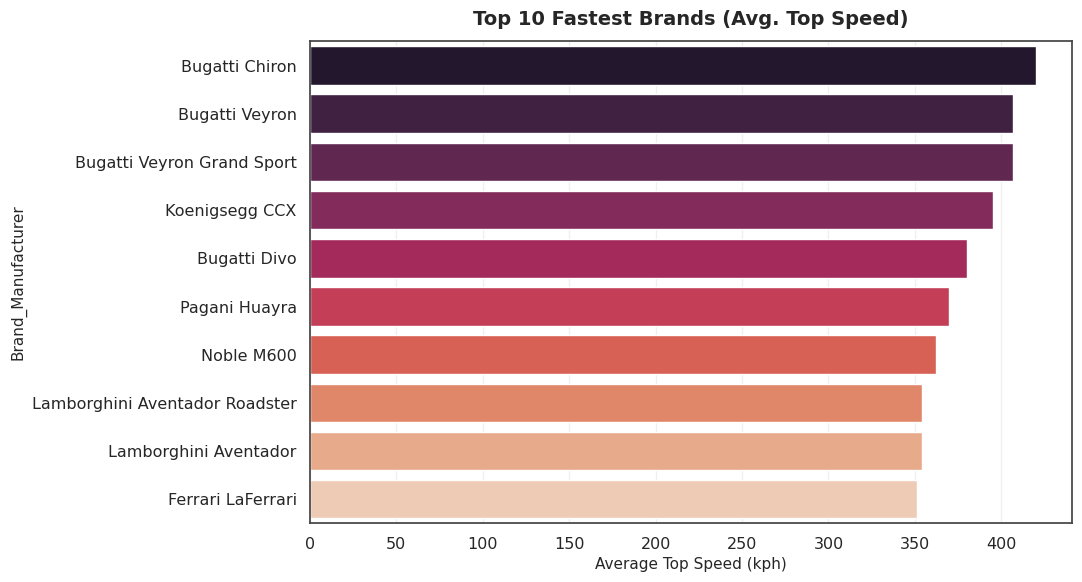

In [ ]:
top_speed_brand = df.groupby("Brand_Manufacturer")["Top speed (kph)"].mean().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=top_speed_brand.values, y=top_speed_brand.index, hue=top_speed_brand.index, palette="rocket", legend=False, ax=ax)
ax.set_title("Top 10 Fastest Brands (Avg. Top Speed)")
ax.set_xlabel("Average Top Speed (kph)")
plt.tight_layout()
plt.show()

In [ ]:
fig = px.scatter(
    df, x="Approx Cost", y="Performance 0-100 kph (sec)",
    color="Power (hp)", size="Top speed (kph)",
    hover_data=["Brand_Manufacturer", "Model Year"],
    template=PLOTLY_TEMPLATE,
    title="Cost vs 0-100 Performance (color = Power)",
    color_continuous_scale="viridis",
)
fig.update_layout(height=600)
fig.show()

In [ ]:
yearly = df.groupby("Model Year")["Top speed (kph)"].mean().reset_index()
fig = px.line(yearly, x="Model Year", y="Top speed (kph)", markers=True,
              template=PLOTLY_TEMPLATE, title="Average Top Speed Over Model Years")
fig.show()